In [79]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
import joblib 

# Load data
iris = load_iris()

# Masukkan ke dalam DataFrame agar kita bisa melihatnya seperti tabel biasa
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

# Tampilkan 5 data teratas
print(df_iris.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [80]:
X =df_iris.drop(columns=['target'])
y = df_iris['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
model_iris = LogisticRegression(max_iter=1000)
model_iris.fit(X_train, y_train)
prediksi_iris = model_iris.predict(X_test)

In [82]:
prediksi_model = accuracy_score(y_test, prediksi_iris)

cm = confusion_matrix(y_test, prediksi_iris)

print("Akurasi Model:", prediksi_model)
print("Confusion Matrix:\n", cm)

Akurasi Model: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [83]:
skor_cv = cross_val_score(model_iris, X, y, cv=5)
print("lima skor:", skor_cv)
print("Rata-rata skor:", skor_cv.mean())

lima skor: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Rata-rata skor: 0.9733333333333334


rata-rata skor Decision Tree: 0.9533333333333334


<module 'matplotlib.pyplot' from '/opt/anaconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

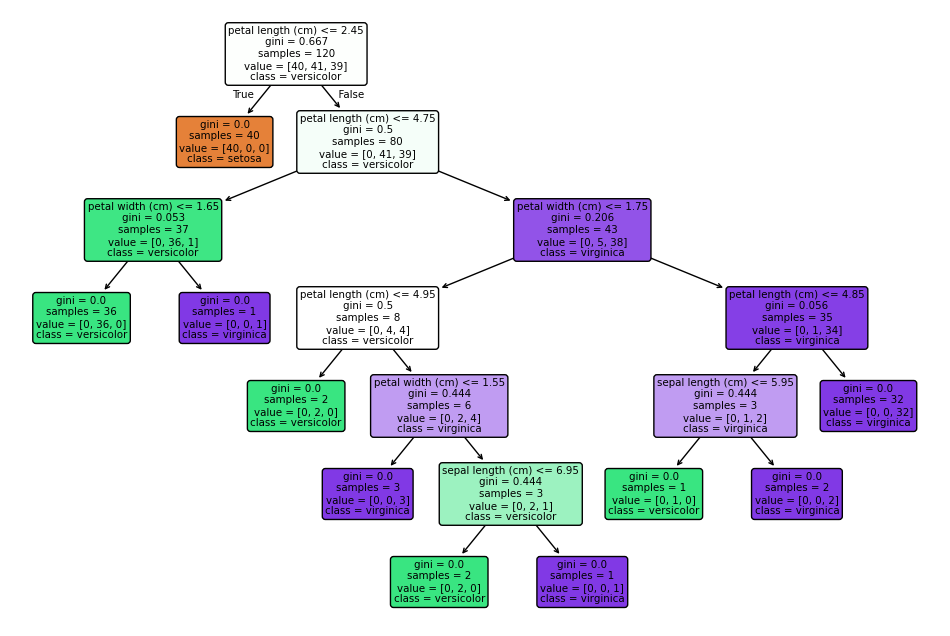

In [84]:
model_tree = DecisionTreeClassifier()
model_tree.fit(X_train, y_train)

skor_cv_tree = cross_val_score(model_tree, X, y, cv=5)
print("rata-rata skor Decision Tree:", skor_cv_tree.mean())

plt.figure(figsize=(12,8))

plot_tree(model_tree, feature_names=iris.feature_names, class_names=['setosa', 'versicolor', 'virginica'], filled=True, rounded=True)

plt

In [85]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

skor_cv_rf = cross_val_score(model_rf, X, y, cv=5)
print("rata-rata skor Random Forest:", skor_cv_rf.mean())

rata-rata skor Random Forest: 0.9666666666666668


In [86]:
joblib.dump(model_rf, 'model_random_forest.pkl')

['model_random_forest.pkl']

In [90]:
model_load = joblib.load('model_random_forest.pkl')

prediksi_rf = model_load.predict(X_test)
jawaban_rf = accuracy_score(y_test, prediksi_rf)
print("predik", prediksi_rf)
print("Akurasi Random Forest:", jawaban_rf)

predik [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Akurasi Random Forest: 1.0
